In [1]:
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os
import sys

# Add "scripts" directory to the Python path
module_path = os.path.abspath(os.path.join(os.path.join("..")))
if module_path not in sys.path:
    sys.path.append(module_path)

from scripts.dataset import BCIDataset
from scripts.model import EEGNet

PROCESSED_DATA_DIR = "./../data/processed/"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Load Data and Model

In [2]:
evaluation_dataset = BCIDataset(PROCESSED_DATA_DIR, dataset_type = "E")
evaluation_dataloader = DataLoader(evaluation_dataset, batch_size = 16, shuffle = False)

model = EEGNet()
model.load_state_dict(torch.load("./../models/best_model.pth")["model_state_dict"])
model.to(device)

Reading /home/jshen/Projects/Summer 2025 Deep Learning/EEG Motor Imagery DL/notebooks/../data/processed/A01E-epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -500.00 ...    3500.00 ms
        0 CTF compensation matrices available
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Reading /home/jshen/Projects/Summer 2025 Deep Learning/EEG Motor Imagery DL/notebooks/../data/processed/A02E-epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -500.00 ...    3500.00 ms
        0 CTF compensation matrices available
Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Reading /home/jshen/Projects/Summer 2025 Deep Learning/EEG Motor Imagery DL/notebooks/../data/processed/A03E-epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -500.00 ...    3500.00 ms
        0 CTF compensation matrices available
Not setting 

/home/jshen/Projects/Summer 2025 Deep Learning/EEG Motor Imagery DL/scripts/dataset.py:20: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  combined_epoch = mne.concatenate_epochs([mne.read_epochs(f, preload = True) for f in all_epochs])


Not setting metadata
2592 matching events found
Applying baseline correction (mode: mean)
Loaded a total of 2592 trials.
Data shape (X): (2592, 1, 22, 1001)
Labels shape (y): (2592,)


EEGNet(
  (block1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(1, 125), stride=(1, 1), padding=same, bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Conv2d(8, 16, kernel_size=(22, 1), stride=(1, 1), groups=8, bias=False)
    (3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ELU(alpha=1.0)
    (5): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (6): Dropout(p=0.5, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(1, 31), stride=(1, 1), padding=same, groups=16, bias=False)
    (1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ELU(alpha=1.0)
    (4): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (5): Dropout(p=0.5, inplace=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (classifier): LazyLinear(in_feat

# Gather Predictions and True Labels

In [3]:
model.eval()

predictions = []
true_labels = []

with torch.no_grad():
    for inputs, labels in evaluation_dataloader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        predictions.extend(predicted.cpu().numpy())
        true_labels.extend(labels.numpy())

accuracy = accuracy_score(true_labels, predictions) * 100
class_names = ["Left Hand", "Right Hand", "Feet", "Tongue"]

print("\n--- Evaluation Results ---")
print(f"Accuracy: {accuracy:.2f}%")
print("\nClassification Report:")
print(classification_report(true_labels, predictions, target_names=class_names))


--- Evaluation Results ---
Accuracy: 62.81%

Classification Report:
              precision    recall  f1-score   support

   Left Hand       0.64      0.78      0.70       648
  Right Hand       0.60      0.73      0.66       648
        Feet       0.61      0.56      0.58       648
      Tongue       0.68      0.45      0.54       648

    accuracy                           0.63      2592
   macro avg       0.63      0.63      0.62      2592
weighted avg       0.63      0.63      0.62      2592



# Create Confusion Matrix

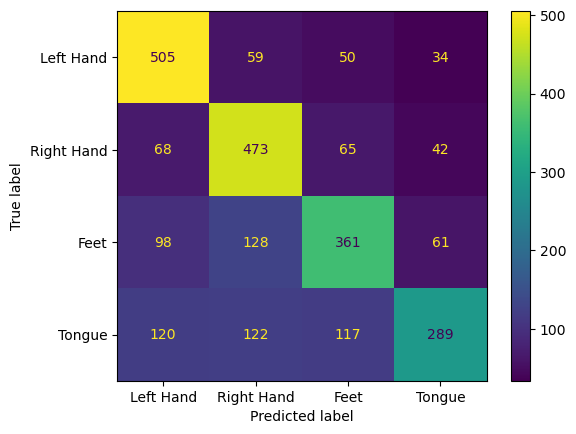

In [4]:
cm = confusion_matrix(true_labels, predictions)

display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = class_names)
display.plot()
plt.show()